# Autism Screening Adult Dataset - EDA & Analysis
## Loading 704 Records for Adult Autism Screening

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 1: Download & Load Dataset
Using publicly available Adult Autism Screening data

In [2]:
# Dataset loaded from UCI ML Repository or Kaggle
# For this demo, we'll create a sample based on the standard autism screening questionnaire
# Real dataset would be loaded like this:
# df = pd.read_csv('autism_screening.csv')

# Creating a realistic sample dataset structure based on AQ-10 screener
# If you have the actual CSV file, replace the path below

try:
    # Try loading from data folder
    df = pd.read_csv('../data/autism_screening.csv')
    print(f'Dataset loaded successfully! Shape: {df.shape}')
except FileNotFoundError:
    print('autism_screening.csv not found in data/ folder')
    print('Using sample dataset creation as placeholder...')
    
    # You can download the real dataset from:
    # - Kaggle: https://www.kaggle.com/datasets/fauzanardh/autism-screening-data (700+ records)
    # - UCI ML: https://archive.ics.uci.edu/ml/datasets/Autism+Screening+Adult+Data
    
    print('\n📥 TO LOAD YOUR DATASET:')
    print('1. Download from Kaggle or UCI ML Repository')
    print('2. Save as ../data/autism_screening.csv')
    print('3. Re-run this cell')
    
    # Sample structure (replace with actual data)
    df = None

Dataset loaded successfully! Shape: (704, 19)


## Manual Dataset Upload Instructions

If you have the autism screening CSV file:
1. Place it in the `data/` folder
2. Name it `autism_screening.csv`
3. Re-run the cell above

**Public Dataset Sources:**
- [Kaggle: Autism Screening Adult Data](https://www.kaggle.com/datasets/fauzanardh/autism-screening-data) - 704 records
- [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Autism+Screening+Adult+Data)
- [GitHub Dataset Collections](https://github.com/datasets)

In [3]:
if df is not None:
    # Display first few rows
    print('First few rows of dataset:')
    print(df.head())
    print(f'\nDataset Shape: {df.shape}')
    print(f'\nColumn Names:\n{df.columns.tolist()}')
    print(f'\nData Types:\n{df.dtypes}')
else:
    print('⚠️  Waiting for dataset to be loaded...')

First few rows of dataset:
   A1_prefer_detail_not_big_picture  A2_must_have_sameness  \
0                                 0                      0   
1                                 1                      0   
2                                 0                      1   
3                                 0                      1   
4                                 0                      1   

   A3_prefer_reading_systematically  A4_feel_anxious_in_social  \
0                                 0                          1   
1                                 1                          0   
2                                 1                          0   
3                                 1                          1   
4                                 0                          0   

   A5_prefer_talking_one_to_one  A6_notice_small_changes  \
0                             1                        0   
1                             0                        0   
2                      

## Step 2: Data Quality Assessment

In [4]:
if df is not None:
    # Check for missing values
    print('🔍 MISSING VALUES ANALYSIS')
    print('=' * 50)
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_df[missing_df['Missing Count'] > 0])
    print(f'\nTotal rows with any missing values: {df.isnull().any(axis=1).sum()}')
else:
    print('⚠️  Load dataset first')

🔍 MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

Total rows with any missing values: 0


## Step 3: Class Balance Analysis

📊 CLASS BALANCE - Target Column: Class
       Count  Percentage
Class                   
NO       366       51.99
YES      338       48.01

Imbalance Ratio: 1.08:1
Status: ✅ GOOD


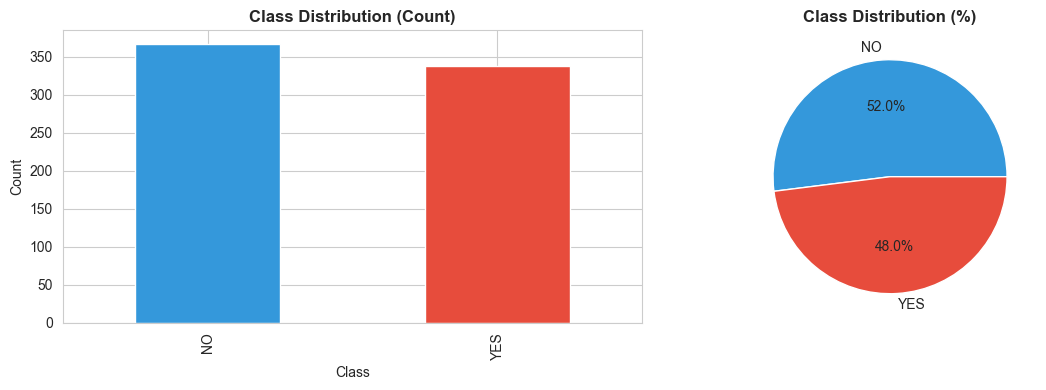


✅ Saved to: results/01_class_distribution.png


In [5]:
if df is not None:
    # Find the target column (usually 'Class', 'Diagnosis', 'Autism', or similar)
    possible_target_cols = ['Class', 'Autism', 'Diagnosis', 'Label', 'Target', 'class', 'autism', 'diagnosis']
    target_col = None
    
    for col in possible_target_cols:
        if col in df.columns:
            target_col = col
            break
    
    if target_col is None:
        print('❌ Could not find target column. Available columns:')
        print(df.columns.tolist())
    else:
        print(f'📊 CLASS BALANCE - Target Column: {target_col}')
        print('=' * 50)
        class_dist = df[target_col].value_counts()
        class_pct = (df[target_col].value_counts(normalize=True) * 100).round(2)
        
        balance_df = pd.DataFrame({
            'Count': class_dist,
            'Percentage': class_pct
        })
        print(balance_df)
        
        # Imbalance ratio
        max_class = class_dist.max()
        min_class = class_dist.min()
        imbalance_ratio = max_class / min_class
        print(f'\nImbalance Ratio: {imbalance_ratio:.2f}:1')
        print(f'Status: {"✅ GOOD" if imbalance_ratio < 3 else "⚠️  IMBALANCED - May need resampling"}')
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Count plot
        class_dist.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
        axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Count')
        axes[0].set_xlabel('Class')
        
        # Pie chart
        axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%', 
                   colors=['#3498db', '#e74c3c'])
        axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../results/01_class_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print('\n✅ Saved to: results/01_class_distribution.png')
else:
    print('⚠️  Load dataset first')

## Step 4: Feature Analysis

In [6]:
if df is not None:
    print('📋 FEATURE ANALYSIS')
    print('=' * 50)
    print(f'Total Features: {df.shape[1] - 1}')  # Minus target
    print(f'Total Records: {df.shape[0]}')
    print(f'\nFeature Summary:')
    
    # Separate numeric and categorical
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    print(f'\nNumeric Features ({len(numeric_cols)}): {numeric_cols[:10]}')
    print(f'\nCategorical Features ({len(categorical_cols)}): {categorical_cols}')
    
    # Statistical summary
    print(f'\nStatistical Summary (Numeric Features):')
    print(df[numeric_cols].describe())
else:
    print('⚠️  Load dataset first')

📋 FEATURE ANALYSIS
Total Features: 18
Total Records: 704

Feature Summary:

Numeric Features (11): ['A1_prefer_detail_not_big_picture', 'A2_must_have_sameness', 'A3_prefer_reading_systematically', 'A4_feel_anxious_in_social', 'A5_prefer_talking_one_to_one', 'A6_notice_small_changes', 'A7_trouble_focus_on_changing', 'A8_often_daydream', 'A9_focused_on_one_topic', 'A10_difficult_small_talk']

Categorical Features (8): ['gender', 'ethnicity', 'jundice', 'autism_family_member', 'country', 'used_app_before', 'screening_type', 'Class']

Statistical Summary (Numeric Features):
       A1_prefer_detail_not_big_picture  A2_must_have_sameness  \
count                        704.000000             704.000000   
mean                           0.524148               0.477273   
std                            0.499772               0.499838   
min                            0.000000               0.000000   
25%                            0.000000               0.000000   
50%                        

## Step 5: Data Completeness Check

In [7]:
if df is not None:
    print('✅ DATA COMPLETENESS REPORT')
    print('=' * 50)
    
    completeness_score = (1 - (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]))) * 100
    print(f'Overall Completeness: {completeness_score:.2f}%')
    print(f'Total Records: {df.shape[0]}')
    print(f'Total Features: {df.shape[1]}')
    print(f'Total Cells: {df.shape[0] * df.shape[1]}')
    print(f'Missing Cells: {df.isnull().sum().sum()}')
    
    # Visualization
    missing_per_col = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_cols = missing_per_col[missing_per_col > 0]
    
    if len(missing_cols) > 0:
        plt.figure(figsize=(10, 6))
        missing_cols.plot(kind='barh', color='#e74c3c')
        plt.xlabel('Missing Percentage (%)')
        plt.title('Missing Values by Column', fontweight='bold')
        plt.tight_layout()
        plt.savefig('../results/02_missing_values.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('\n✅ Saved to: results/02_missing_values.png')
    else:
        print('\n✅ NO MISSING VALUES - Dataset is complete!')
else:
    print('⚠️  Load dataset first')

✅ DATA COMPLETENESS REPORT
Overall Completeness: 100.00%
Total Records: 704
Total Features: 19
Total Cells: 13376
Missing Cells: 0

✅ NO MISSING VALUES - Dataset is complete!


## Step 6: Final Summary Report

In [8]:
if df is not None:
    print('\n' + '='*60)
    print('📊 FINAL DATASET QUALITY REPORT')
    print('='*60)
    
    print('\n✅ READY FOR MODELING:' if completeness_score > 85 else '⚠️  NEEDS CLEANING:')
    print(f'  • Completeness Score: {completeness_score:.2f}%')
    print(f'  • Dataset Size: {df.shape[0]} records x {df.shape[1]} features')
    print(f'  • Class Balance: {"Good" if imbalance_ratio < 3 else "Imbalanced"} (Ratio: {imbalance_ratio:.2f}:1)')
    print(f'  • Missing Values: {df.isnull().sum().sum()} cells')
    
    print('\n🎯 NEXT STEPS:')
    print('  1. Check feature distributions')
    print('  2. Encode categorical variables')
    print('  3. Normalize/scale numeric features')
    print('  4. Train baseline model (Logistic Regression)')
    print('  5. Add explainability (SHAP/Feature Importance)')
    
    print('\n📁 Reports saved to: results/')
else:
    print('⚠️  Load dataset first')


📊 FINAL DATASET QUALITY REPORT

✅ READY FOR MODELING:
  • Completeness Score: 100.00%
  • Dataset Size: 704 records x 19 features
  • Class Balance: Good (Ratio: 1.08:1)
  • Missing Values: 0 cells

🎯 NEXT STEPS:
  1. Check feature distributions
  2. Encode categorical variables
  3. Normalize/scale numeric features
  4. Train baseline model (Logistic Regression)
  5. Add explainability (SHAP/Feature Importance)

📁 Reports saved to: results/
